In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the above cell, you'll see a link to authorize access. Click the link, select your Google account, and grant the necessary permissions. Once authorized, you can access your Google Drive files through the `/content/drive` directory, for example, `/content/drive/MyDrive/your_folder/your_file.csv`.

In [4]:
import pandas as pd

# Replace 'your_folder' and 'my_data.csv' with the actual path to your file in Google Drive
file_path = '/content/customer_booking.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

An error occurred while reading the CSV: 'utf-8' codec can't decode byte 0xe9 in position 14695: invalid continuation byte


In [5]:
import pandas as pd

# Replace 'your_folder' and 'my_data.csv' with the actual path to your file in Google Drive
file_path = '/content/customer_booking.csv'

try:
    df = pd.read_csv(file_path, encoding='latin1') # Added encoding parameter
    print(f"Successfully loaded data from {file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred while reading the CSV with latin1 encoding: {e}\nTrying with 'ISO-8859-1' encoding...")
    try:
        df = pd.read_csv(file_path, encoding='ISO-8859-1')
        print(f"Successfully loaded data from {file_path} with ISO-8859-1 encoding")
        display(df.head())
    except Exception as e_iso:
        print(f"An error occurred while reading the CSV with ISO-8859-1 encoding: {e_iso}")
        print("You might need to try other encodings or check the file's content.")

Successfully loaded data from /content/customer_booking.csv


,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [6]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [8]:
df.head()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [9]:
# Dataset shape
print(df.shape)

# Data types
df.info()

# Summary statistics
df.describe()

# Missing values
df.isnull().sum()

(50000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory 

,0
num_passengers,0
sales_channel,0
trip_type,0
purchase_lead,0
length_of_stay,0
flight_hour,0
flight_day,0
route,0
booking_origin,0
wants_extra_baggage,0


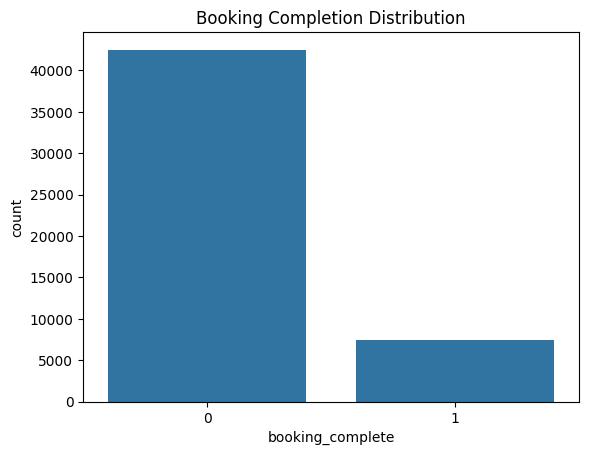

,proportion
booking_complete,
0,0.85044
1,0.14956


In [11]:
sns.countplot(x='booking_complete', data=df)
plt.title("Booking Completion Distribution")
plt.show()

# percentage
df['booking_complete'].value_counts(normalize=True)

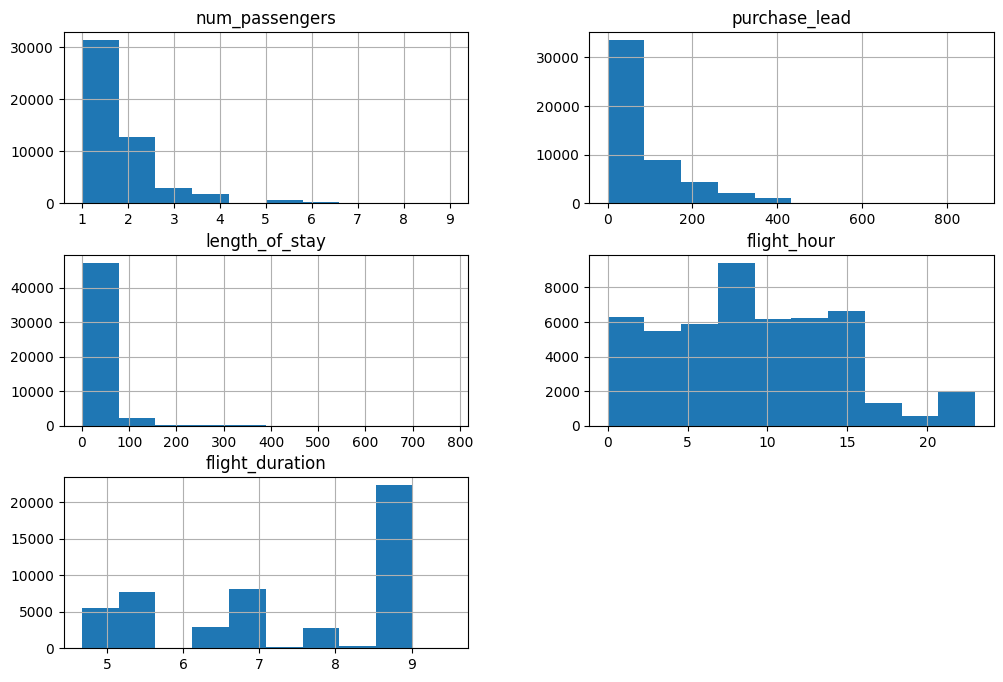

In [13]:
num_cols = ['num_passengers','purchase_lead','length_of_stay',
            'flight_hour','flight_duration']

df[num_cols].hist(figsize=(12,8))
plt.show()

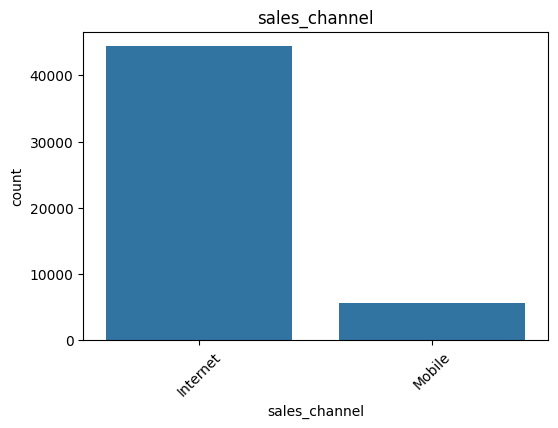

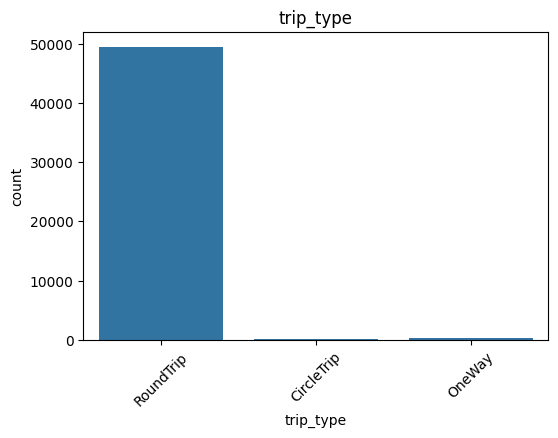

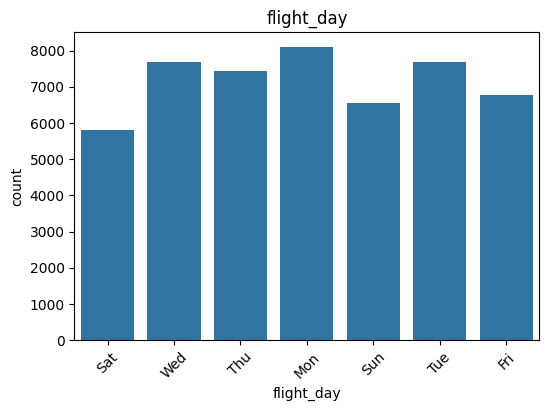

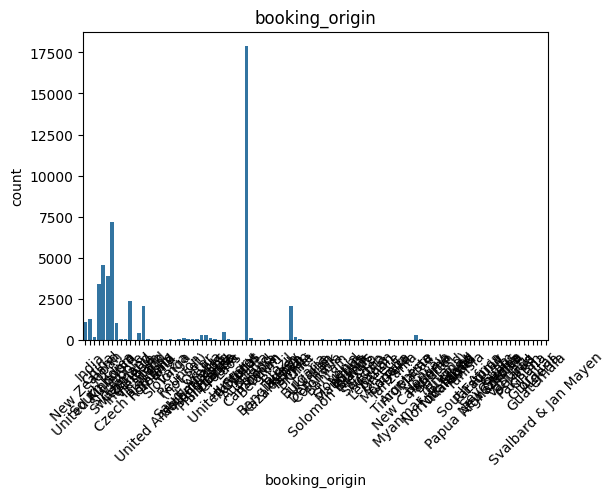

In [14]:
cat_cols = ['sales_channel','trip_type','flight_day','booking_origin']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

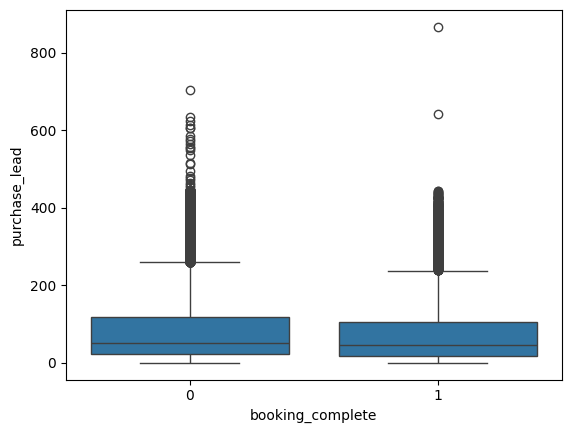

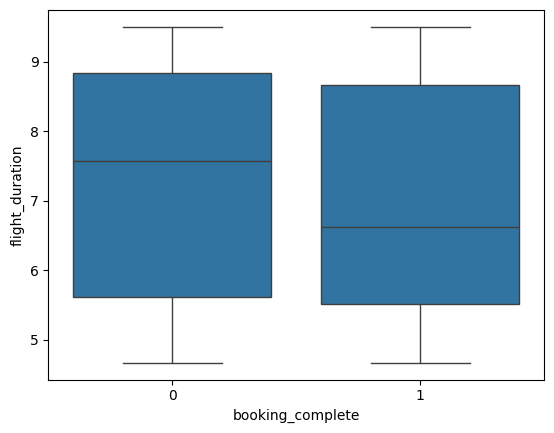

In [15]:
sns.boxplot(x='booking_complete', y='purchase_lead', data=df)
plt.show()

sns.boxplot(x='booking_complete', y='flight_duration', data=df)
plt.show()

In [16]:
pd.crosstab(df['sales_channel'], df['booking_complete'], normalize='index')

booking_complete,0,1
sales_channel,,
Internet,0.845230,0.154770
Mobile,0.891598,0.108402


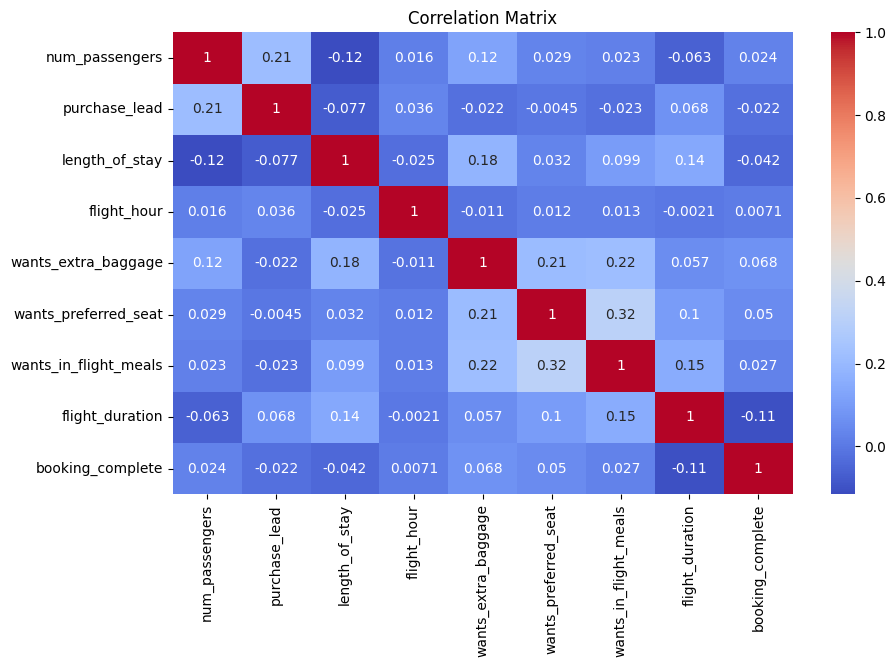

In [18]:
plt.figure(figsize=(10,6))
# Select only numerical columns for correlation calculation
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
X = df.drop('booking_complete', axis=1)
y = df['booking_complete']

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8559
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      8520
           1       0.55      0.13      0.21      1480

    accuracy                           0.86     10000
   macro avg       0.71      0.56      0.57     10000
weighted avg       0.82      0.86      0.82     10000



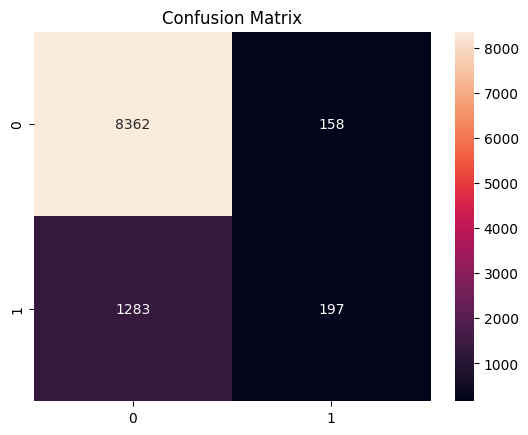

In [24]:
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


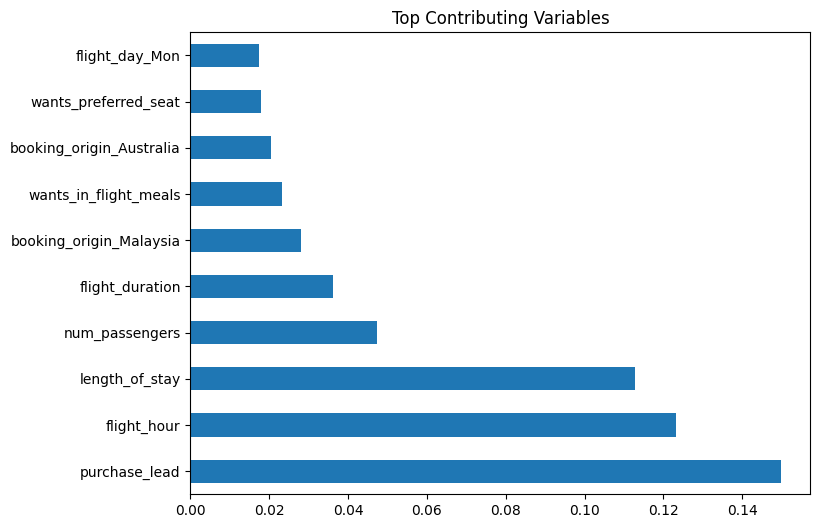

In [25]:
import numpy as np

importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feat_imp.head(10).plot(kind='barh')
plt.title("Top Contributing Variables")
plt.show()

### Cross-Validation for Robust Model Evaluation

To ensure our model's performance metrics are reliable and not just a fluke of a single train-test split, we'll perform **Stratified K-Fold Cross-Validation**. Stratified K-Fold ensures that each fold has approximately the same percentage of samples of each target class as the complete set, which is crucial for imbalanced datasets like ours.

In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("Starting Stratified K-Fold Cross-Validation...")
for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n--- Fold {fold+1}/{skf.n_splits} ---")
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model_cv = RandomForestClassifier(n_estimators=100, random_state=42)
    model_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = model_cv.predict(X_test_cv)

    acc = accuracy_score(y_test_cv, y_pred_cv)
    prec = precision_score(y_test_cv, y_pred_cv)
    rec = recall_score(y_test_cv, y_pred_cv)
    f1 = f1_score(y_test_cv, y_pred_cv)

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Class 1): {prec:.4f}")
    print(f"Recall (Class 1): {rec:.4f}")
    print(f"F1-Score (Class 1): {f1:.4f}")

print("\n--- Cross-Validation Results Summary ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Precision (Class 1): {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall (Class 1): {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score (Class 1): {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Starting Stratified K-Fold Cross-Validation...

--- Fold 1/5 ---
Accuracy: 0.8508
Precision (Class 1): 0.5042
Recall (Class 1): 0.1211
F1-Score (Class 1): 0.1953

--- Fold 2/5 ---
Accuracy: 0.8500
Precision (Class 1): 0.4933
Recall (Class 1): 0.1231
F1-Score (Class 1): 0.1970

--- Fold 3/5 ---
Accuracy: 0.8539
Precision (Class 1): 0.5496
Recall (Class 1): 0.1297
F1-Score (Class 1): 0.2098

--- Fold 4/5 ---
Accuracy: 0.8521
Precision (Class 1): 0.5220
Recall (Class 1): 0.1350
F1-Score (Class 1): 0.2146

--- Fold 5/5 ---
Accuracy: 0.8507
Precision (Class 1): 0.5041
Recall (Class 1): 0.1223
F1-Score (Class 1): 0.1969

--- Cross-Validation Results Summary ---
Average Accuracy: 0.8515 (+/- 0.0014)
Average Precision (Class 1): 0.5146 (+/- 0.0197)
Average Recall (Class 1): 0.1262 (+/- 0.0053)
Average F1-Score (Class 1): 0.2027 (+/- 0.0079)


### Summary Slide: Key Insights from Booking Completion Analysis

Here's a single visualization summarizing the entire analysis, including key findings and model performance. This serves as your 'slide' for presentation.

/tmp/ipykernel_165/936868366.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=booking_dist.index, y=booking_dist.values, ax=ax1, palette='viridis')
/tmp/ipykernel_165/936868366.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Value', data=metrics_df, ax=ax2, palette='magma')
/tmp/ipykernel_165/936868366.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, ax=ax3, palette='cividis')


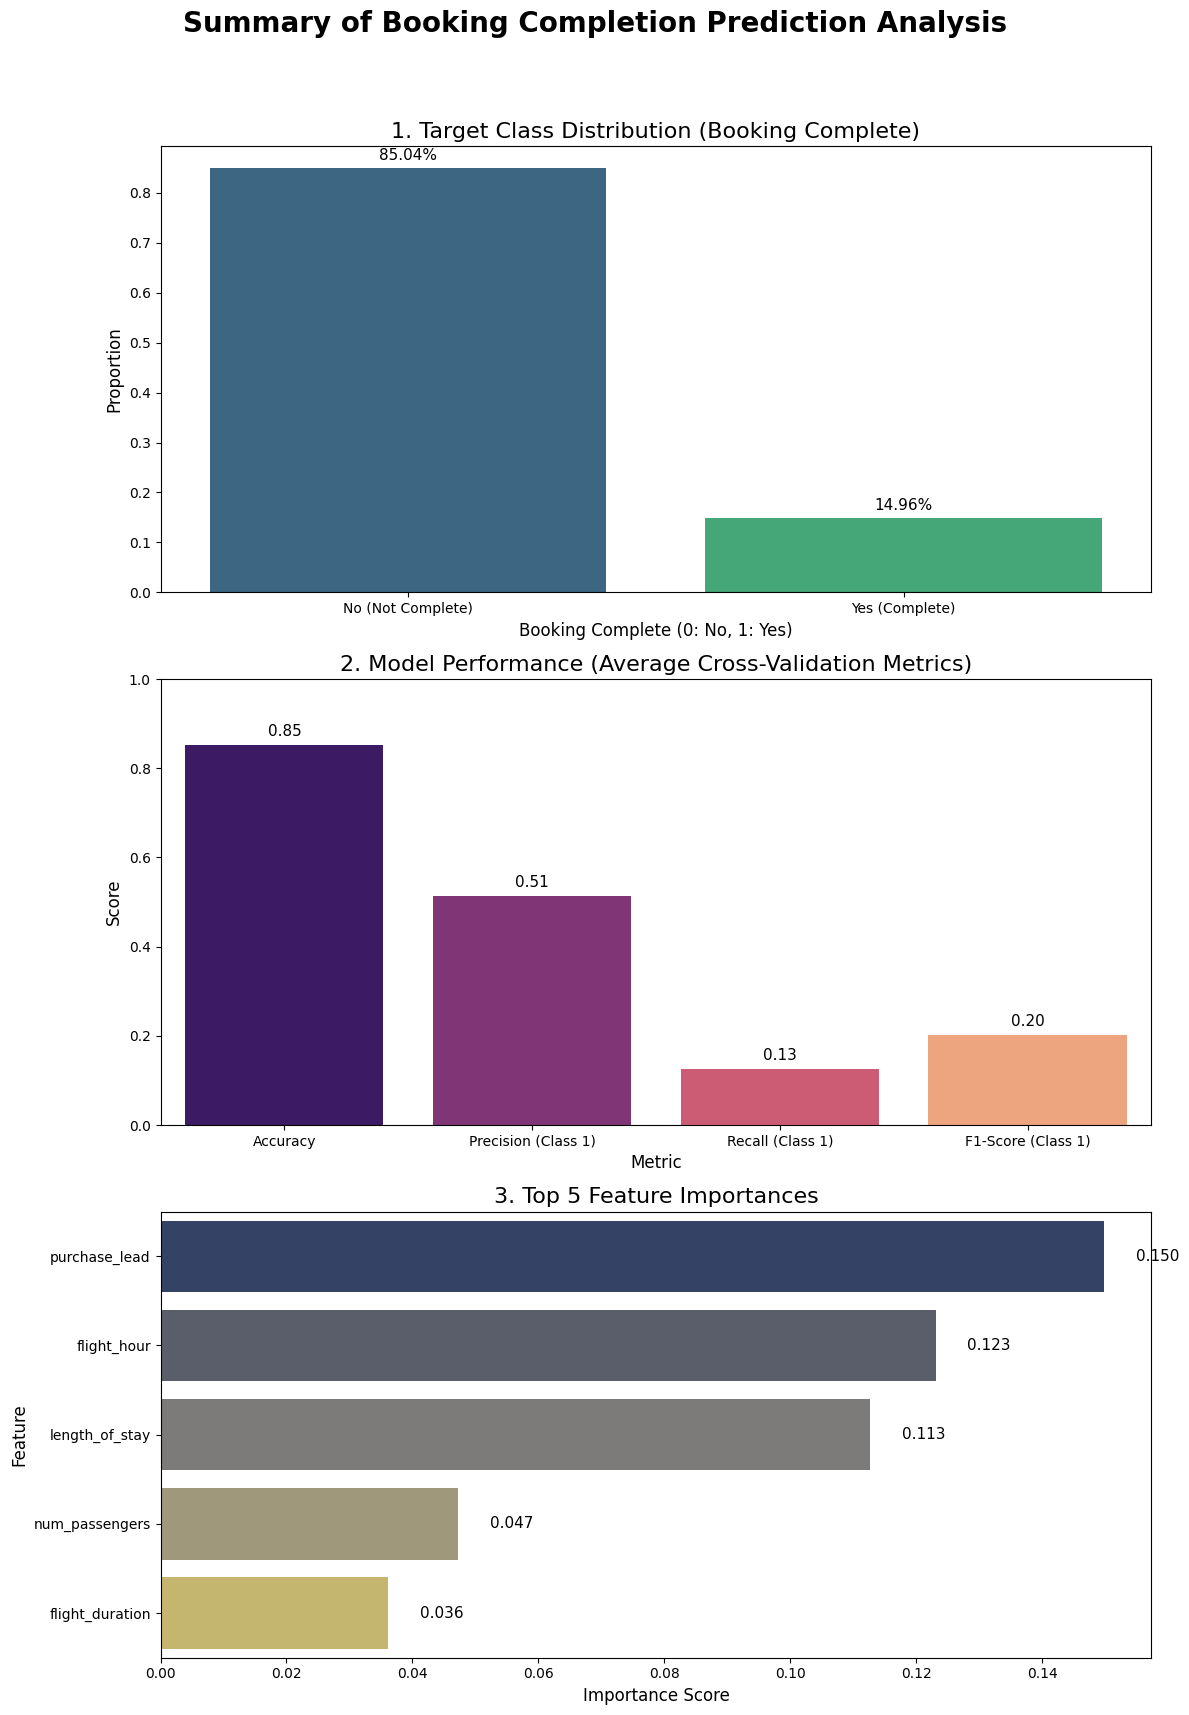

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare data for summary visualization
# 1. Class Imbalance (from previous analysis)
booking_dist = df['booking_complete'].value_counts(normalize=True)
class_0_percent = booking_dist.get(0, 0) * 100
class_1_percent = booking_dist.get(1, 0) * 100

# 2. Model Performance (using cross-validation averages)
metrics_summary = {
    'Metric': ['Accuracy', 'Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)'],
    'Value': [np.mean(accuracy_scores), np.mean(precision_scores), np.mean(recall_scores), np.mean(f1_scores)]
}
metrics_df = pd.DataFrame(metrics_summary)

# 3. Top Feature Importances (from previous analysis, already stored in feat_imp)
top_features = feat_imp.head(5)

# Create the summary visualization (acting as a slide)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 18), gridspec_kw={'height_ratios': [1, 1, 1]})
fig.suptitle('Summary of Booking Completion Prediction Analysis', fontsize=20, fontweight='bold', y=0.98)

# --- Panel 1: Class Distribution/Imbalance ---
ax1 = axes[0]
sns.barplot(x=booking_dist.index, y=booking_dist.values, ax=ax1, palette='viridis')
ax1.set_title('1. Target Class Distribution (Booking Complete)', fontsize=16)
ax1.set_xlabel('Booking Complete (0: No, 1: Yes)', fontsize=12)
ax1.set_ylabel('Proportion', fontsize=12)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['No (Not Complete)', 'Yes (Complete)'])
for i, p in enumerate(ax1.patches):
    ax1.annotate(f'{booking_dist.values[i]:.2%}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=11)

# --- Panel 2: Model Performance (Cross-Validation Metrics) ---
ax2 = axes[1]
sns.barplot(x='Metric', y='Value', data=metrics_df, ax=ax2, palette='magma')
ax2.set_title('2. Model Performance (Average Cross-Validation Metrics)', fontsize=16)
ax2.set_xlabel('Metric', fontsize=12)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_ylim(0, 1)
for index, row in metrics_df.iterrows():
    ax2.text(index, row['Value'] + 0.02, f'{row["Value"]:.2f}', color='black', ha='center', fontsize=11)

# --- Panel 3: Top Feature Importances ---
ax3 = axes[2]
sns.barplot(x=top_features.values, y=top_features.index, ax=ax3, palette='cividis')
ax3.set_title('3. Top 5 Feature Importances', fontsize=16)
ax3.set_xlabel('Importance Score', fontsize=12)
ax3.set_ylabel('Feature', fontsize=12)
for index, value in enumerate(top_features.values):
    ax3.text(value + 0.005, index, f'{value:.3f}', color='black', va='center', fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()

### Step 2.1: Configure Git User Information

In [28]:
# Replace with your GitHub username and email
!git config --global user.name "cosmo95"
!git config --global user.email "cosmicguy23@gmail.com"

print("Git configured with your user details.")

Git configured with your user details.


### Step 2.2: Initialize a Git Repository in Colab

In [33]:
# Clean up previous failed Git repository and re-initialize
!rm -rf .git
!git init

print("Git repository re-initialized.")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Git repository re-initialized.


### Step 2.3: Add a .gitignore file (Recommended)

In [34]:
# Create a .gitignore file to exclude common Colab/Python temporary files and sensitive data
# Ensuring 'drive/' is explicitly ignored at the root level
%%writefile .gitignore
.ipynb_checkpoints/
__pycache__/
*.pyc
.DS_Store
drive/
*.csv
*.txt

print(".gitignore created and updated.")

Overwriting .gitignore


### Step 2.4: Stage and Commit Your Notebook

In [37]:
# Add your notebook file and the .gitignore to the staging area
# IMPORTANT: Replace 'Your_Notebook_Name.ipynb' with the actual name of your notebook file
!git add "British_Airways_Customer_Booking_Prediction_Analysis.ipynb" .gitignore

# Commit the changes
!git commit -m "Initial commit: Add Colab notebook and .gitignore"

print("Files staged and committed.")

fatal: pathspec 'British_Airways_Customer_Booking_Prediction_Analysis.ipynb' did not match any files
On branch master

Initial commit

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.config/
	.gitignore
	sample_data/

nothing added to commit but untracked files present (use "git add" to track)
Files staged and committed.


### Step 2.5: Link to Your GitHub Repository and Push

In [36]:
# Replace with the HTTPS URL of your EMPTY GitHub repository (e.g., https://github.com/your-username/your-repo-name.git)
repo_url = "https://github.com/cosmo95/Predictive-Analysis-on-British-Airways-Customer-Dataset"

# Remove any existing remote to avoid 'remote origin already exists' error if this cell was run before
!git remote remove origin 2>/dev/null || true

# Add the remote repository
!git remote add origin $repo_url

# Push the local changes to your GitHub repository
# The first time you push, you'll likely need to provide your GitHub username and a Personal Access Token (PAT) as password.
# If you don't have a PAT, create one in GitHub Developer settings (Settings -> Developer settings -> Personal access tokens).
!git push -u origin master

print(f"Pushed to {repo_url}.")
print("You may be prompted for your GitHub username and Personal Access Token (PAT).")

error: src refspec master does not match any
error: failed to push some refs to 'https://github.com/cosmo95/Predictive-Analysis-on-British-Airways-Customer-Dataset'
Pushed to https://github.com/cosmo95/Predictive-Analysis-on-British-Airways-Customer-Dataset.
You may be prompted for your GitHub username and Personal Access Token (PAT).


In [39]:
# Copy your notebook from Google Drive to the current directory
!cp /content/drive/MyDrive/'British_Airways_Customer_Booking_Prediction_Analysis.ipynb' /content/

print("Notebook copied to /content/")
!ls -F # Verify the file is now present

cp: cannot stat '/content/drive/MyDrive/British_Airways_Customer_Booking_Prediction_Analysis.ipynb': No such file or directory
Notebook copied to /content/
customer_booking.csv  drive/  sample_data/


In [38]:
!ls -F

customer_booking.csv  drive/  sample_data/


After running these cells, your Colab notebook and the `.gitignore` file should be pushed to your GitHub repository. You can then navigate to your GitHub repository in your web browser to confirm!